In [162]:
import numpy as np
import pandas as pd
import pwlf
import matplotlib.pyplot as plt

In [163]:
# === 参数 ===
excel_file = '../data/test_data.xlsx'  # Excel 文件名（与脚本放同目录）
fit_start_date = '2025-04-05'
fit_end_date = '2025-04-09'
predict_date = '2025-04-10'
n_segments = 3  # CoPiLinear 拟合段数

In [164]:
# === 读取数据 ===
df = pd.read_excel(excel_file)
df['date'] = pd.to_datetime(df['date'])

# === 拟合模型 ===
fit_df = df[(df['date'] >= fit_start_date) & (df['date'] <= fit_end_date)]
x = fit_df['load_rate'].values
y = fit_df['price'].values

# 定义权重：同样对 x<=0.3 和 x>0.7 数据赋予较大权重
weights = np.ones_like(x)
weights[x <= 0.7] = 3.0
weights[x >= 0.92] = 3.0

# 初始参数猜测
model = pwlf.PiecewiseLinFit(x, y, weights=weights)
# 拟合3段线性函数（不需要在 fit 中再传 weights 参数）
breaks = model.fit(n_segments)  

In [165]:
x_hat= np.linspace(min(x), max(x), num=100)
y_hat = model.predict(x_hat)

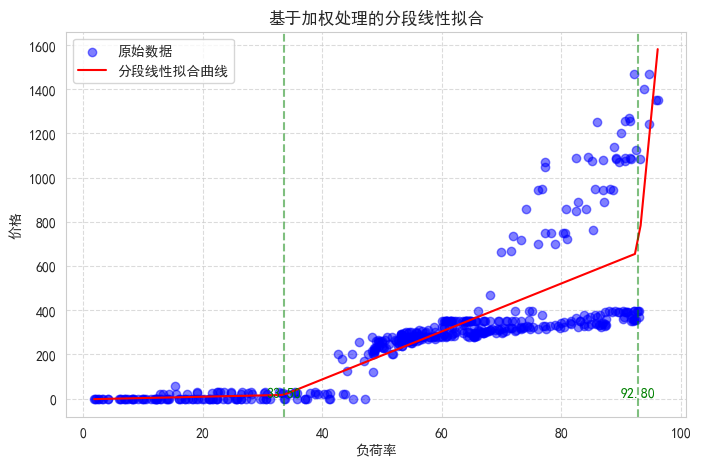

分段点位置: [33.50200046 92.8       ]
拟合系数: [ -2.25211676   0.59948878  10.25411253 268.37545368]


In [166]:
plt.figure(figsize=(8, 5))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.scatter(x, y, c='blue', label='原始数据', alpha=0.5)
plt.plot(x_hat, y_hat, 'r-', label='分段线性拟合曲线')

# 显示分段点位置
for b in breaks[1:-1]:  # 跳过第一个和最后一个边界点
    plt.axvline(x=b, color='green', linestyle='--', alpha=0.5)
    plt.text(b, min(y), f'{b:.2f}', ha='center', va='bottom', color='green')

plt.xlabel('负荷率')
plt.ylabel('价格')
plt.legend()
plt.title('基于加权处理的分段线性拟合')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. 打印拟合结果信息
print(f"分段点位置: {breaks[1:-1]}")  # 只打印内部分段点
print(f"拟合系数: {model.beta}")


In [167]:
predict_df = df[df['date'] == predict_date]
x_pre = predict_df['load_rate']
y_pre = model.predict(x_pre)

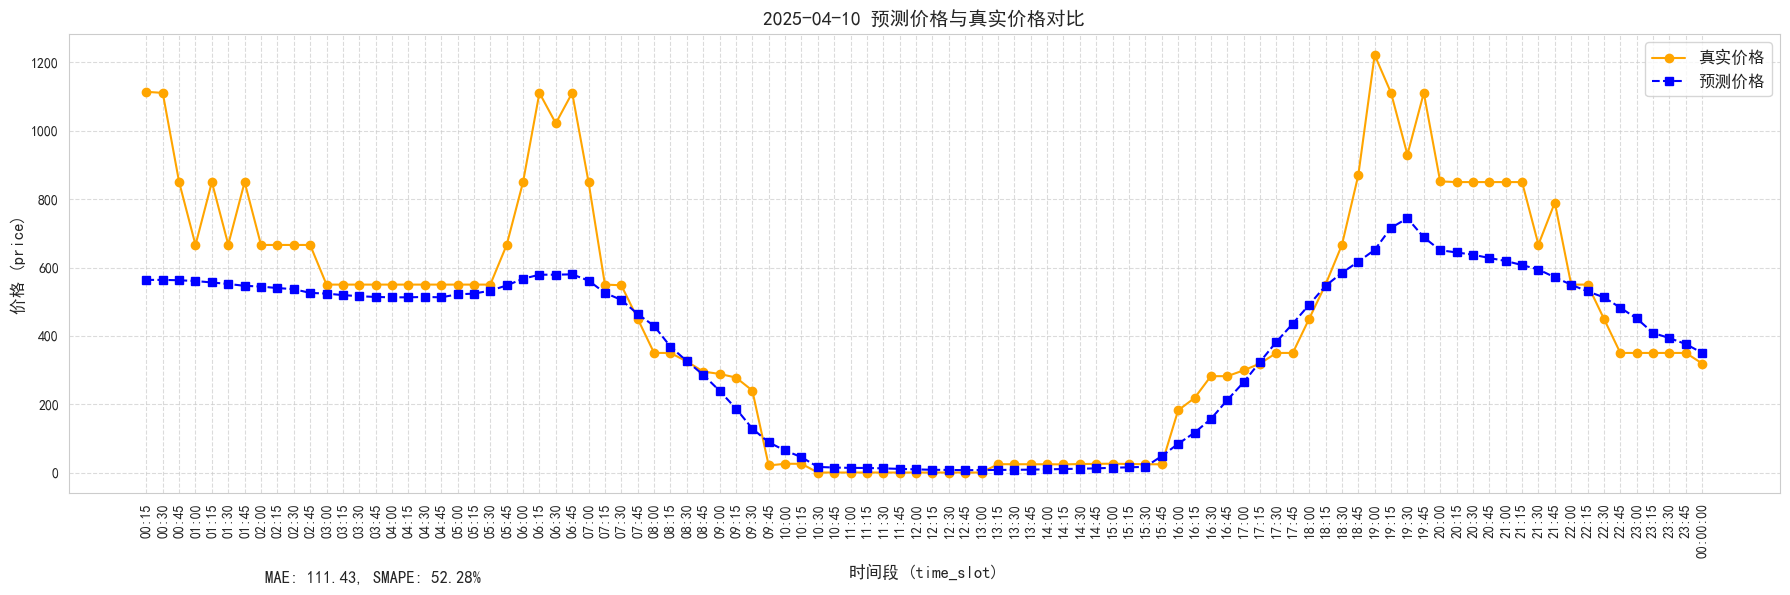

In [168]:
# === 绘制预测价格与真实价格的对比图 ===
plt.figure(figsize=(18, 6))

# 创建一个数值索引用于绘图
x_indices = range(len(predict_df))

# 绘制真实价格
plt.plot(x_indices, predict_df['price'], 'o-', color='orange', label='真实价格', markersize=6)

# 绘制预测价格
plt.plot(x_indices, y_pre, 's--', color='blue', label='预测价格', markersize=6)

# 添加图表标题和标签
plt.title(f'{predict_date} 预测价格与真实价格对比', fontsize=14)
plt.xlabel('时间段 (time_slot)', fontsize=12)
plt.ylabel('价格 (price)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 将time_slot转换为字符串用于x轴标签
time_labels = [str(ts) for ts in predict_df['time_slot']]
plt.xticks(x_indices, time_labels, rotation=90)

# 添加误差信息
mae = np.mean(np.abs(predict_df['price'] - y_pre))
#mape = np.mean(np.abs((predict_df['price'] - y_pre) / predict_df['price'])) * 100
# SMAPE计算，避免除零问题
smape = np.mean(2.0 * np.abs(predict_df['price'] - y_pre) / (np.abs(predict_df['price']) + np.abs(y_pre) + 1e-10)) * 100
plt.figtext(0.15, 0.02, f'MAE: {mae:.2f}, SMAPE: {smape:.2f}%', fontsize=12)

plt.tight_layout()
plt.show()


In [169]:
# 打印预测值和真实值的对比表格
comparison_df = predict_df[['date', 'time_slot', 'load_rate', 'price']].copy()
comparison_df['predicted_price'] = y_pre
comparison_df['error'] = comparison_df['price'] - comparison_df['predicted_price']
comparison_df['error_percent'] = (comparison_df['error'] / comparison_df['price']) * 100
print("预测值与真实值对比:")
print(comparison_df)

预测值与真实值对比:
          date time_slot  load_rate    price  predicted_price       error  \
864 2025-04-10     00:15       83.9  1114.14       563.752671  550.387329   
865 2025-04-10     00:30       83.9  1111.00       563.752671  547.247329   
866 2025-04-10     00:45       83.8   850.00       562.667310  287.332690   
867 2025-04-10     01:00       83.6   666.00       560.496590  105.503410   
868 2025-04-10     01:15       83.2   850.00       556.155150  293.844850   
..         ...       ...        ...      ...              ...         ...   
955 2025-04-10     23:00       73.5   350.00       450.875217 -100.875217   
956 2025-04-10     23:15       69.6   350.00       408.546172  -58.546172   
957 2025-04-10     23:30       68.2   350.00       393.351130  -43.351130   
958 2025-04-10     23:45       66.6   350.00       375.985368  -25.985368   
959 2025-04-10  00:00:00       64.2   319.00       349.936725  -30.936725   

     error_percent  
864      49.400195  
865      49.257185  
8